In [1]:
from pathlib import Path

import numpy as onp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
# Replace with path to results of your own benchmark runs to plot them:

RESULTSDIR = Path("example_results") / "nonperiodic"
# RESULTSDIR = Path("example_results") / "nonperiodic_doubleprec"
# RESULTSDIR = Path("example_results") / "periodic"
# RESULTSDIR = Path("example_results") / "periodic_doubleprec"

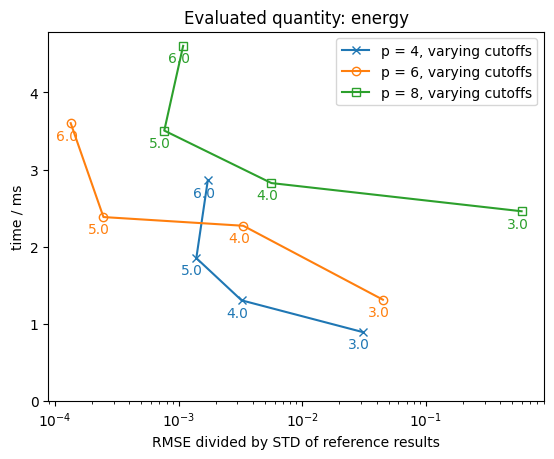

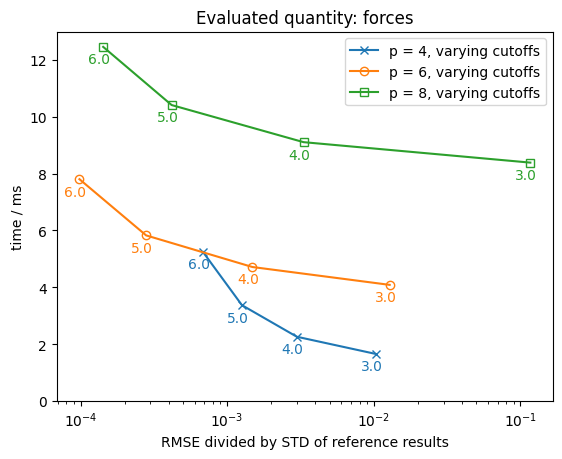

In [3]:
markerlist = ["x", "o", "s", "d", "v", "^"]

results = pd.read_csv(RESULTSDIR / "results.csv")

unique_quantities = results["quantity"].unique()

# Settings for annotating the data points with the cutoff value:
# See https://matplotlib.org/stable/users/explain/artists/transforms_tutorial.html#using-offset-transforms-to-create-a-shadow-effect for the handling of the annotation offsets from the data points
ha = "center"
va = "top"
dx, dy = -3 / 72.0, -4 / 72.0  # x and y offsets in points

for quantity in unique_quantities:
    unique_ps = results.loc[results["quantity"] == quantity, "p"].unique()
    unique_ps = onp.sort(unique_ps)

    fig, ax = plt.subplots()
    ax.set_title("Evaluated quantity: " + quantity)
    ax.set_xlabel("RMSE divided by STD of reference results")
    ax.set_ylabel("time / ms")
    ax.set_xscale("log")
    offset = mpl.transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)
    annotations_transform = ax.transData + offset
    for p, marker in zip(unique_ps, markerlist):
        selection = results.loc[
            ((results["p"] == p) & (results["quantity"] == quantity))
        ]
        cutoffs = selection.level_zero_cutoff
        errors = selection.relative_rmse
        times = selection.time * 10**3
        graph = ax.plot(
            errors,
            times,
            marker=marker,
            markerfacecolor="none",
            label=f"p = {p}, varying cutoffs",
        )
        for r_cut, err, t in zip(cutoffs, errors, times):
            xy = (err, t)
            ax.annotate(
                str(r_cut),
                xy,
                xytext=xy,
                textcoords=annotations_transform,
                ha=ha,
                va=va,
                color=graph[0].get_color(),
            )

    ax.set_ylim(0.0, ax.get_ylim()[1])
    ax.legend()

    filename_without_suffix = f"cost_vs_accuracy_{quantity}"
    for suffix in [".png", ".pdf"]:
        fig.savefig(RESULTSDIR / (filename_without_suffix + suffix))

    plt.show()